In [100]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
import shap
from models import *
from utilities import *

In [102]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('font', family='sans-serif') 
matplotlib.rc('font', serif='Helvetica Neue') 

In [103]:
##########################################################################################################

In [104]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Eager mode:", tf.executing_eagerly())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.15.0
Eager mode: True
GPUs: []


In [105]:
# shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [106]:
################### data import ###############

In [107]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')

In [108]:
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [109]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)

In [110]:
ba_copy = ba_copy.fillna(0)
data_copy = data_copy.fillna(0)

In [112]:
len(data_copy.SCCRIP_ID.unique())

1267

In [113]:
feature_dy = data_copy.drop(['HU_status','Id_encoded','SCCRIP_ID', 'date'],axis=1).columns
feature_ba = ba_copy.drop(['Id_encoded'], axis=1).columns

In [114]:
################ data process ##################

In [115]:
seq_length = 5

In [116]:
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

In [117]:
(X_train,X_val,X_test,
            X_bg_train,X_bg_val,X_bg_test,
            dt_train, dt_val, dt_test, 
            y_train,y_val,y_test,
            ls_train, ls_val, ls_test,
            seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)


In [118]:
# Initialize the model class
combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]))

Model input shapes: (None, 5, 786) (None, 1, 23) (None, 1, 1)
Model: "CombinedLSTMModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_bg (InputLayer)       [(None, 1, 23)]              0         []                            
                                                                                                  
 input_dt (InputLayer)       [(None, 1, 1)]               0         []                            
                                                                                                  
 input_seq (InputLayer)      [(None, 5, 786)]             0         []                            
                                                                                                  
 bg_plus_dt (Concatenate)    (None, 1, 24)                0         ['input_bg[0][0]',            
                    

In [119]:
# Train the model
history = combined_model.train(
    X_train, X_bg_train, dt_train, y_train,
    X_val,   X_bg_val,   dt_val,   y_val,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/mix_best2.h5"
)

Epoch 1/20
294/294 [==============================] - ETA: 0s - loss: 132.2738 - mean_absolute_error: 7.5938
Epoch 1: val_loss improved from inf to 19.94436, saving model to ../results/models/mix_best2.h5
294/294 [==============================] - 4s 8ms/step - loss: 132.2738 - mean_absolute_error: 7.5938 - val_loss: 19.9444 - val_mean_absolute_error: 3.1732
Epoch 2/20
292/294 [============================>.] - ETA: 0s - loss: 19.4549 - mean_absolute_error: 2.9990
Epoch 2: val_loss did not improve from 19.94436
294/294 [==============================] - 2s 7ms/step - loss: 19.4798 - mean_absolute_error: 3.0036 - val_loss: 24.1305 - val_mean_absolute_error: 3.5767
Epoch 3/20
293/294 [============================>.] - ETA: 0s - loss: 12.1968 - mean_absolute_error: 2.3494
Epoch 3: val_loss improved from 19.94436 to 12.14535, saving model to ../results/models/mix_best2.h5
294/294 [==============================] - 2s 7ms/step - loss: 12.1918 - mean_absolute_error: 2.3490 - val_loss: 12.145

In [120]:
# Load the model
combined_model.save("../results/models/mix_best2.h5")
combined_model.load("../results/models/mix_best2.h5")

In [121]:
# Make predictions on the test set
y_pred = combined_model.predict(X_test, X_bg_test, dt_test)

175/175 [==============================] - 1s 2ms/step


In [122]:
figure_dir = '../results/figures/mix/'
ensure_directory_exists(figure_dir)

Directory '../results/figures/mix/' already exists.


Mean Squared Error: 12.3879
Mean Absolute Error: 2.3485
R^2 Score: 0.8922
r: 0.9449


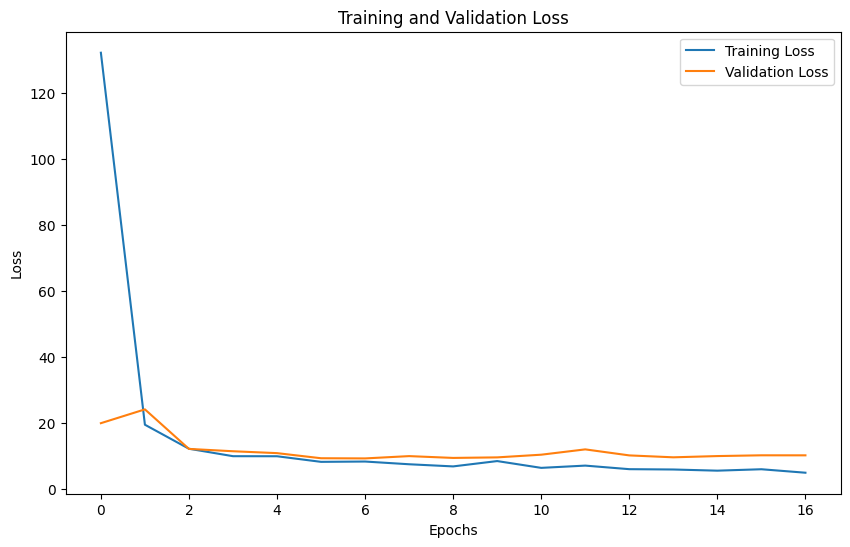

In [123]:
from scipy.stats import pearsonr
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
r2 = r2_score(y_test.flatten(), y_pred.flatten())
r, _  = pearsonr(y_test.flatten(), y_pred.flatten())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"r: {r:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# plt.savefig(figure_dir + 'LOSS.pdf')
plt.show()

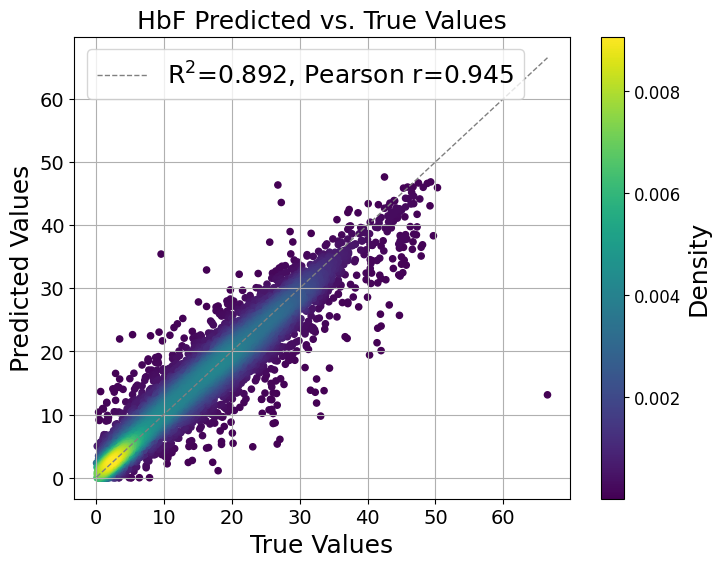

In [124]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_grey", ["#B3B3B3", "#4D4D4D"])

from scipy.stats import gaussian_kde, linregress

y_test = y_test.reshape(y_test.shape[0])
y_pred = y_pred.reshape(y_pred.shape[0])
xy = np.vstack([y_test, y_pred])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test, y_pred, z = y_test[idx], y_pred[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test,
    y_pred,
    c=z,
    cmap='viridis',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'R$^2$={r2:.3f}, Pearson r={r:.3f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
# plt.xlim([0,80])
# plt.ylim([0,80])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('HbF Predicted vs. True Values', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
# plt.savefig(figure_dir+'dot_dot.pdf')

In [125]:
###############################################

In [126]:
r2 = []
shap_impact = []
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)
while len(r2) < 20:
    print (len(r2))
    (X_train,X_val,X_test,
                X_bg_train,X_bg_val,X_bg_test,
                dt_train, dt_val, dt_test, 
                y_train,y_val,y_test,
                ls_train, ls_val, ls_test,
                seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)
    
    combined_model_l = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]), summary=False)
    
    history = combined_model_l.train(
    X_train, X_bg_train, dt_train, y_train,
    X_val,   X_bg_val,   dt_val,   y_val,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/Mix_best2_loop.h5")
    y_pred = combined_model_l.predict(X_test, X_bg_test, dt_test)
    r2_ = r2_score(y_test.flatten(), y_pred.flatten())
    if r2_ > 0:
        r2.append(r2_)

        explainer = shap.GradientExplainer(combined_model_l.model, [X_test, X_bg_test, dt_test])
        shap_values = explainer.shap_values([X_test, X_bg_test, dt_test])

        shap_val_d = []
        train_d = []

        for i in range (5):
            shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
            train_d.append(pd.DataFrame(X_test[:,i,:],columns=feature_dy))
            
        shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
        train_b = pd.DataFrame(X_bg_test[:,0,:], columns=feature_ba)

        impact_dy = []

        for i in range(5):
            im = ABS_SHAP(shap_val_d[i], train_d[i])
            impact_dy.append(im)
            
        impact_ba = ABS_SHAP(shap_val_b, train_b)

        shap_impact.append((impact_dy, impact_ba))

0
Epoch 1/20
289/295 [============================>.] - ETA: 0s - loss: 123.5147 - mean_absolute_error: 7.1670
Epoch 1: val_loss improved from inf to 26.92460, saving model to ../results/models/Mix_best2_loop.h5
295/295 [==============================] - 4s 8ms/step - loss: 121.4535 - mean_absolute_error: 7.0826 - val_loss: 26.9246 - val_mean_absolute_error: 3.5336
Epoch 2/20
289/295 [============================>.] - ETA: 0s - loss: 18.1439 - mean_absolute_error: 2.8520
Epoch 2: val_loss improved from 26.92460 to 22.33379, saving model to ../results/models/Mix_best2_loop.h5
295/295 [==============================] - 2s 6ms/step - loss: 18.0897 - mean_absolute_error: 2.8516 - val_loss: 22.3338 - val_mean_absolute_error: 3.3676
Epoch 3/20
289/295 [============================>.] - ETA: 0s - loss: 12.0800 - mean_absolute_error: 2.3170
Epoch 3: val_loss improved from 22.33379 to 16.99560, saving model to ../results/models/Mix_best2_loop.h5
295/295 [==============================] - 2s 6ms

In [135]:
with open('../results/data/mix/shap_impact_list.pkl','wb') as f:
    pickle.dump(shap_impact,f)

In [128]:
########################################## Shap Below

In [129]:
# combined_model.load("../results/models/mix_best2.h5")

In [130]:
# explainer = shap.DeepExplainer(combined_model.model, [X_test, X_bg_test, dt_test])
# shap_values = explainer.shap_values([X_test, X_bg_test, dt_test])

In [131]:
# with open('../results/data/mix/shap_values.pkl', 'wb') as f:
#     pickle.dump(shap_values, f)

In [132]:
# shap_val_d = []
# train_d = []

# for i in range (5):
#     shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
#     train_d.append(pd.DataFrame(X_test[:,i,:],columns=feature_dy))
    
# shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
# train_b = pd.DataFrame(X_bg_test[:,0,:], columns=feature_ba)

In [133]:
# impact_dy = []

# for i in range(5):
#     im = ABS_SHAP(shap_val_d[i], train_d[i])
#     impact_dy.append(im)
    
# impact_ba = ABS_SHAP(shap_val_b, train_b)

In [134]:
# with open('../results/data/mix/shap_impact.pkl', 'wb') as f:
#     pickle.dump((impact_dy,impact_ba), f)